In [ ]:
import os
import sys
import json
import textwrap
import subprocess
import shutil
from pathlib import Path
from getpass import getpass
from collections import Counter, defaultdict

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "openai>=1.30.0", "pyyaml>=6.0", "matplotlib>=3.8"])
REPO_DIR = Path("/content/a-evolve")
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)
subprocess.check_call(["git", "clone", "--depth", "1", "https://github.com/A-EVO-Lab/a-evolve.git", str(REPO_DIR)])
sys.path.insert(0, str(REPO_DIR))

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ").strip()

OPENAI_MODEL = "gpt-4o-mini"

import yaml
import matplotlib.pyplot as plt

import agent_evolve as ae
from agent_evolve.protocol.base_agent import BaseAgent
from agent_evolve.benchmarks.base import BenchmarkAdapter
from agent_evolve.engine.base import EvolutionEngine
from agent_evolve.types import Task, Trajectory, Feedback, StepResult
from agent_evolve.contract.workspace import AgentWorkspace
from openai import OpenAI

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

WORKSPACE_ROOT = Path("/content/a_evolve_demo_workspace")
if WORKSPACE_ROOT.exists():
    shutil.rmtree(WORKSPACE_ROOT)

(WORKSPACE_ROOT / "prompts").mkdir(parents=True, exist_ok=True)
(WORKSPACE_ROOT / "skills").mkdir(parents=True, exist_ok=True)
(WORKSPACE_ROOT / "memory").mkdir(parents=True, exist_ok=True)
(WORKSPACE_ROOT / "tools").mkdir(parents=True, exist_ok=True)

manifest = {
    "name": "colab-aevolve-demo-agent",
    "version": "0.1.0",
    "contract_version": "1.0",
    "agent": {
        "type": "custom",
        "entrypoint": None
    },
    "evolvable_layers": ["prompts", "skills", "memory"],
    "reload_strategy": "hot"
}
with open(WORKSPACE_ROOT / "manifest.yaml", "w") as f:
    yaml.dump(manifest, f, sort_keys=False)

initial_system_prompt = textwrap.dedent("""
You are a precise text-transformation agent.

Solve the task exactly.
Be concise.
Return only the final answer with no explanation unless the task explicitly asks for JSON.
""").strip()

(WORKSPACE_ROOT / "prompts" / "system.md").write_text(initial_system_prompt)

In [ ]:
def build_dataset():
    train = [
        {
            "id": "train-01",
            "rule": "json_sum",
            "input": "Numbers: 7, 11, 4",
            "answer": '{"sum":22}'
        },
        {
            "id": "train-02",
            "rule": "json_sum",
            "input": "Numbers: 20, 5, 3, 2",
            "answer": '{"sum":30}'
        },
        {
            "id": "train-03",
            "rule": "acronym_upper",
            "input": "Create the acronym from: retrieval augmented generation",
            "answer": "RAG"
        },
        {
            "id": "train-04",
            "rule": "acronym_upper",
            "input": "Create the acronym from: large language model",
            "answer": "LLM"
        },
        {
            "id": "train-05",
            "rule": "pipe_unique_sorted_lower",
            "input": "Tokens: Banana, apple, banana, Cherry, apple",
            "answer": "apple|banana|cherry"
        },
        {
            "id": "train-06",
            "rule": "pipe_unique_sorted_lower",
            "input": "Tokens: Zebra, ant, zebra, Lion, ant, lion",
            "answer": "ant|lion|zebra"
        },
        {
            "id": "train-07",
            "rule": "vowel_parity",
            "input": "Word: equation",
            "answer": "EVEN"
        },
        {
            "id": "train-08",
            "rule": "vowel_parity",
            "input": "Word: education",
            "answer": "ODD"
        },
    ]

    holdout = [
        {
            "id": "holdout-01",
            "rule": "json_sum",
            "input": "Numbers: 100, 1, 9",
            "answer": '{"sum":110}'
        },
        {
            "id": "holdout-02",
            "rule": "acronym_upper",
            "input": "Create the acronym from: artificial general intelligence",
            "answer": "AGI"
        },
        {
            "id": "holdout-03",
            "rule": "pipe_unique_sorted_lower",
            "input": "Tokens: Mango, apple, mango, Berry, berry",
            "answer": "apple|berry|mango"
        },
        {
            "id": "holdout-04",
            "rule": "vowel_parity",
            "input": "Word: aeroplane",
            "answer": "ODD"
        },
    ]
    return train, holdout

TRAIN_DATA, HOLDOUT_DATA = build_dataset()

def normalize_text(x: str) -> str:
    return x.strip().replace(" ", "")

class MiniTextBenchmark(BenchmarkAdapter):
    def __init__(self):
        self.train = TRAIN_DATA
        self.holdout = HOLDOUT_DATA

    def get_tasks(self, split: str = "train", limit: int = 10):
        data = self.train if split == "train" else self.holdout
        tasks = []
        for row in data[:limit]:
            tasks.append(
                Task(
                    id=row["id"],
                    input=row["input"],
                    metadata={
                        "rule": row["rule"],
                        "answer": row["answer"]
                    }
                )
            )
        return tasks

    def evaluate(self, task: Task, trajectory: Trajectory):
        pred = trajectory.output.strip()
        gold = task.metadata["answer"].strip()
        success = normalize_text(pred) == normalize_text(gold)
        detail = {
            "rule": task.metadata["rule"],
            "gold": gold,
            "pred": pred,
            "input": task.input,
            "success": success
        }
        score = 1.0 if success else 0.0
        return Feedback(
            success=success,
            score=score,
            detail=json.dumps(detail, ensure_ascii=False),
            raw=detail
        )

SKILL_ROUTING = {
    "json_sum": ["json", "sum"],
    "acronym_upper": ["acronym", "uppercase"],
    "pipe_unique_sorted_lower": ["unique", "sorted", "lowercase", "pipe"],
    "vowel_parity": ["vowel", "odd", "even", "parity"]
}

In [ ]:
class ColabAEResolverAgent(BaseAgent):
    def __init__(self, workspace_dir: str | Path, model: str = OPENAI_MODEL):
        self.model = model
        super().__init__(workspace_dir)

    def _pick_relevant_skills(self, task: Task):
        rule = task.metadata.get("rule", "")
        selected = []
        for skill in self.skills:
            hay = f"{skill.name} {skill.description}".lower()
            if rule == "json_sum" and ("json" in hay or "sum" in hay):
                selected.append(skill)
            elif rule == "acronym_upper" and ("acronym" in hay or "uppercase" in hay):
                selected.append(skill)
            elif rule == "pipe_unique_sorted_lower" and any(k in hay for k in ["unique", "sorted", "lowercase", "pipe"]):
                selected.append(skill)
            elif rule == "vowel_parity" and any(k in hay for k in ["vowel", "odd", "even", "parity"]):
                selected.append(skill)
        return selected[:3]

    def solve(self, task: Task) -> Trajectory:
        relevant_skills = self._pick_relevant_skills(task)
        relevant_skill_texts = []
        for s in relevant_skills:
            relevant_skill_texts.append(self.get_skill_content(s.name))

        memory_text = "\n".join(
            [f"- {m.get('content', '')}" for m in self.memories[-8:]]
        ).strip()

        skill_block = "\n\n".join(relevant_skill_texts).strip()
        if not skill_block:
            skill_block = "(no skills loaded yet)"

        if not memory_text:
            memory_text = "(no memory yet)"

        user_prompt = textwrap.dedent(f"""
        TASK RULE: {task.metadata.get("rule")}
        TASK INPUT:
        {task.input}

        ACTIVE SYSTEM PROMPT:
        {self.system_prompt}

        RELEVANT SKILLS:
        {skill_block}

        RECENT MEMORIES:
        {memory_text}

        Solve the task exactly.
        Return only the final answer.
        """).strip()

        response = client.chat.completions.create(
            model=self.model,
            temperature=0,
            messages=[
                {"role": "system", "content": "You are an exact text-transformation agent."},
                {"role": "user", "content": user_prompt}
            ]
        )

        output = (response.choices[0].message.content or "").strip()

        self.remember(
            content=f"Task {task.id} under rule {task.metadata.get('rule')} produced output: {output}",
            category="episodic"
        )

        return Trajectory(
            task_id=task.id,
            output=output,
            steps=[
                {
                    "rule": task.metadata.get("rule"),
                    "used_skills": [s.name for s in relevant_skills],
                    "system_prompt_chars": len(self.system_prompt),
                    "memory_items_seen": len(self.memories)
                }
            ]
        )

SKILL_TEMPLATES = {
    "json_sum": textwrap.dedent("""
        ---
        name: json-sum-exact
        description: Add all integers and output strict compact JSON with the single key sum.
        ---
        # JSON Sum Exact

        Procedure:
        1. Extract all integers from the task input.
        2. Add them.
        3. Return exactly one compact JSON object in this format:
           {"sum":NUMBER}
        4. Do not add spaces, explanations, markdown, or extra keys.
    """).strip(),

    "acronym_upper": textwrap.dedent("""
        ---
        name: acronym-upper-exact
        description: Build an uppercase acronym by taking the first letter of each word.
        ---
        # Acronym Upper Exact

        Procedure:
        1. Identify the phrase after the colon.
        2. Take the first letter of each word.
        3. Convert every letter to uppercase.
        4. Return only the final acronym, with no punctuation or explanation.
    """).strip(),

    "pipe_unique_sorted_lower": textwrap.dedent("""
        ---
        name: pipe-unique-sorted-lower
        description: Normalize tokens to lowercase, deduplicate them, sort ascending, and join them with pipes.
        ---
        # Pipe Unique Sorted Lower

        Procedure:
        1. Read the token list after the colon.
        2. Split by commas.
        3. Trim spaces and lowercase every token.
        4. Remove duplicates.
        5. Sort alphabetically ascending.
        6. Join with "|" and return only the final string.
    """).strip(),

    "vowel_parity": textwrap.dedent("""
        ---
        name: vowel-parity-exact
        description: Count vowels in the word and output ODD or EVEN only.
        ---
        # Vowel Parity Exact

        Procedure:
        1. Read the target word after the colon.
        2. Count vowels using a, e, i, o, u.
        3. If the count is odd, output ODD.
        4. If the count is even, output EVEN.
        5. Return only ODD or EVEN with no extra text.
    """).strip(),
}

PROMPT_APPENDIX = textwrap.dedent("""
## STRICT OUTPUT CONTRACT
- Output only the final answer.
- Never explain your reasoning.
- If a task expects JSON, return compact JSON with exact keys only.
- When a relevant skill exists, follow it literally.
- Exact format is more important than being conversational.
""").strip()

In [ ]:
class ColabMutationEngine(EvolutionEngine):
    def __init__(self):
        self.cycle_count = 0

    def step(self, workspace: AgentWorkspace, observations, history, trial):
        self.cycle_count += 1

        failed_by_rule = defaultdict(list)
        for obs in observations:
            if not obs.feedback.success:
                failed_by_rule[obs.task.metadata["rule"]].append({
                    "task_id": obs.task.id,
                    "input": obs.task.input,
                    "gold": obs.task.metadata["answer"],
                    "pred": obs.trajectory.output
                })

        mutated = False
        summaries = []

        current_prompt = workspace.read_prompt()
        if "STRICT OUTPUT CONTRACT" not in current_prompt:
            workspace.write_prompt(current_prompt.rstrip() + "\n\n" + PROMPT_APPENDIX + "\n")
            mutated = True
            summaries.append("prompt hardened")

        existing_skill_names = {s.name for s in workspace.list_skills()}

        needed_rule_to_skill_name = {
            "json_sum": "json-sum-exact",
            "acronym_upper": "acronym-upper-exact",
            "pipe_unique_sorted_lower": "pipe-unique-sorted-lower",
            "vowel_parity": "vowel-parity-exact",
        }

        for rule, fails in failed_by_rule.items():
            skill_name = needed_rule_to_skill_name[rule]
            if skill_name not in existing_skill_names:
                workspace.write_skill(skill_name, SKILL_TEMPLATES[rule])
                mutated = True
                summaries.append(f"added skill {skill_name}")

            workspace.add_memory({
                "content": f"Cycle {self.cycle_count}: rule={rule} failed {len(fails)} time(s). Common failure pattern: output formatting or procedure mismatch. Gold examples must be followed exactly.",
                "rule": rule,
                "examples": fails[:2]
            }, category="episodic")

        if not failed_by_rule:
            workspace.add_memory({
                "content": f"Cycle {self.cycle_count}: all current training tasks succeeded. Preserve exact formatting behavior."
            }, category="episodic")

        summary = " | ".join(summaries) if summaries else "no mutation needed"
        return StepResult(
            mutated=mutated,
            summary=summary,
            metadata={
                "failed_rules": list(failed_by_rule.keys()),
                "num_failed_rules": len(failed_by_rule),
                "cycle": self.cycle_count
            }
        )

def evaluate_split(agent, benchmark, split="train"):
    tasks = benchmark.get_tasks(split=split, limit=100)
    rows = []
    total = 0
    correct = 0
    for task in tasks:
        traj = agent.solve(task)
        fb = benchmark.evaluate(task, traj)
        rows.append({
            "task_id": task.id,
            "rule": task.metadata["rule"],
            "input": task.input,
            "gold": task.metadata["answer"],
            "pred": traj.output,
            "score": fb.score,
            "success": fb.success
        })
        total += 1
        correct += int(fb.success)
    score = correct / max(total, 1)
    return score, rows

def print_table(rows, title, max_rows=20):
    print("\n" + "=" * 110)
    print(title)
    print("=" * 110)
    shown = rows[:max_rows]
    for r in shown:
        print(f"[{r['task_id']}] rule={r['rule']}")
        print(f"  input : {r['input']}")
        print(f"  gold  : {r['gold']}")
        print(f"  pred  : {r['pred']}")
        print(f"  score : {r['score']}  success={r['success']}")
        print("-" * 110)

def show_workspace(root: Path):
    print("\n" + "=" * 110)
    print("EVOLVED WORKSPACE SNAPSHOT")
    print("=" * 110)
    for path in sorted(root.rglob("*")):
        rel = path.relative_to(root)
        if path.is_dir():
            print(f"[DIR ] {rel}/")
        else:
            print(f"[FILE] {rel}")

def show_skill_contents(root: Path):
    skill_files = sorted((root / "skills").glob("*/SKILL.md"))
    print("\n" + "=" * 110)
    print("SKILL FILES")
    print("=" * 110)
    if not skill_files:
        print("No skill files yet.")
    for sf in skill_files:
        print(f"\n--- {sf.parent.name}/SKILL.md ---")
        print(sf.read_text())

Enter your OpenAI API key: ··········
Baseline train score   : 0.250
Baseline holdout score : 0.500

BASELINE TRAIN RESULTS
[train-01] rule=json_sum
  input : Numbers: 7, 11, 4
  gold  : {"sum":22}
  pred  : 22
  score : 0.0  success=False
--------------------------------------------------------------------------------------------------------------
[train-02] rule=json_sum
  input : Numbers: 20, 5, 3, 2
  gold  : {"sum":30}
  pred  : 30
  score : 0.0  success=False
--------------------------------------------------------------------------------------------------------------
[train-03] rule=acronym_upper
  input : Create the acronym from: retrieval augmented generation
  gold  : RAG
  pred  : RAG
  score : 1.0  success=True
--------------------------------------------------------------------------------------------------------------
[train-04] rule=acronym_upper
  input : Create the acronym from: large language model
  gold  : LLM
  pred  : LLM
  score : 1.0  success=True
--------------

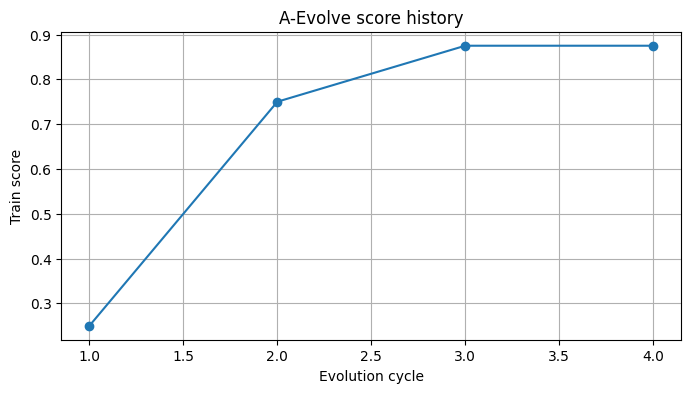


COMPARISON
Train   : 0.250 -> 0.875
Holdout : 0.500 -> 0.750
Improved train cases by rule: {'json_sum': 2, 'pipe_unique_sorted_lower': 2, 'vowel_parity': 1}

Done. This notebook used the real A-Evolve framework and demonstrated:
1) a valid agent workspace
2) a BaseAgent subclass
3) a BenchmarkAdapter subclass
4) an EvolutionEngine subclass
5) prompt / skill / memory mutations across A-Evolve cycles


In [1]:
benchmark = MiniTextBenchmark()
agent = ColabAEResolverAgent(WORKSPACE_ROOT, model=OPENAI_MODEL)
engine = ColabMutationEngine()

baseline_train_score, baseline_train_rows = evaluate_split(agent, benchmark, split="train")
baseline_holdout_score, baseline_holdout_rows = evaluate_split(agent, benchmark, split="holdout")

print(f"Baseline train score   : {baseline_train_score:.3f}")
print(f"Baseline holdout score : {baseline_holdout_score:.3f}")

print_table(baseline_train_rows, "BASELINE TRAIN RESULTS")
print_table(baseline_holdout_rows, "BASELINE HOLDOUT RESULTS")

config = ae.EvolveConfig(
    batch_size=8,
    max_cycles=4,
    egl_window=2
)

evolver = ae.Evolver(
    agent=agent,
    benchmark=benchmark,
    config=config,
    engine=engine
)

result = evolver.run(cycles=4)

print("\n" + "=" * 110)
print("A-EVOLVE RUN SUMMARY")
print("=" * 110)
print(f"Cycles completed : {result.cycles_completed}")
print(f"Final train score: {result.final_score:.3f}")
print(f"Score history    : {result.score_history}")
print(f"Converged        : {result.converged}")

agent.reload_from_fs()
final_train_score, final_train_rows = evaluate_split(agent, benchmark, split="train")
final_holdout_score, final_holdout_rows = evaluate_split(agent, benchmark, split="holdout")

print(f"\nFinal train score   : {final_train_score:.3f}")
print(f"Final holdout score : {final_holdout_score:.3f}")

print_table(final_train_rows, "FINAL TRAIN RESULTS")
print_table(final_holdout_rows, "FINAL HOLDOUT RESULTS")

show_workspace(WORKSPACE_ROOT)
show_skill_contents(WORKSPACE_ROOT)

print("\n" + "=" * 110)
print("FINAL SYSTEM PROMPT")
print("=" * 110)
print((WORKSPACE_ROOT / "prompts" / "system.md").read_text())

episodic_path = WORKSPACE_ROOT / "memory" / "episodic.jsonl"
if episodic_path.exists():
    print("\n" + "=" * 110)
    print("RECENT EPISODIC MEMORY")
    print("=" * 110)
    lines = episodic_path.read_text().strip().splitlines()
    for line in lines[-10:]:
        print(line)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(result.score_history) + 1), result.score_history, marker="o")
plt.xlabel("Evolution cycle")
plt.ylabel("Train score")
plt.title("A-Evolve score history")
plt.grid(True)
plt.show()

print("\n" + "=" * 110)
print("COMPARISON")
print("=" * 110)
print(f"Train   : {baseline_train_score:.3f} -> {final_train_score:.3f}")
print(f"Holdout : {baseline_holdout_score:.3f} -> {final_holdout_score:.3f}")

improved_rules = []
for before, after in zip(sorted(baseline_train_rows, key=lambda x: x["task_id"]), sorted(final_train_rows, key=lambda x: x["task_id"])):
    if (not before["success"]) and after["success"]:
        improved_rules.append(after["rule"])

print(f"Improved train cases by rule: {dict(Counter(improved_rules))}")

print("\nDone. This notebook used the real A-Evolve framework and demonstrated:")
print("1) a valid agent workspace")
print("2) a BaseAgent subclass")
print("3) a BenchmarkAdapter subclass")
print("4) an EvolutionEngine subclass")
print("5) prompt / skill / memory mutations across A-Evolve cycles")